<table>
<tr>                                                                                   
     <th>
         <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'><a href="https://www.kaggle.com/datasets/uciml/mushroom-classification">Courbe ROC (Receiver Operating Characteristic) pour une classification binaire</a></div>
     </th>
     <th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/champignon.jpg" width="56"></th>
 </tr>
</table>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Introduction</div></b>
## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import libriries </div></b>

In [1]:
import pandas as pd, numpy as np, seaborn as sns, warnings, os, sys, time, copy as cp, pickle,re
from datetime import datetime as dt
from matplotlib import pyplot as plt

import matplotlib.font_manager as fm
import matplotlib.patheffects as path_effects

import plotly.express as px
import plotly.graph_objects as go

In [2]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics  import make_scorer, confusion_matrix, roc_curve, auc, accuracy_score, log_loss, hamming_loss, \
                             precision_score, recall_score, f1_score, fbeta_score, jaccard_score,  \
                             precision_recall_curve, average_precision_score, precision_recall_fscore_support, matthews_corrcoef

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils projet</div></b>

In [3]:
sys.path.append(os.path.abspath('../outils/'))
from prjFormation import palette

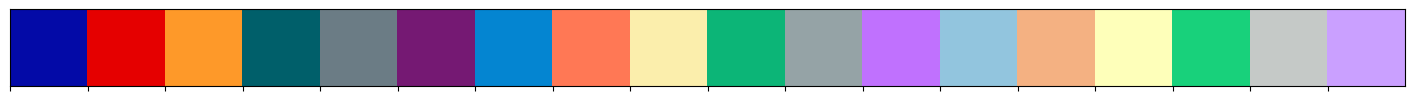

In [4]:
# palette = [ "#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973", 
#             "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe", 
#             "#d1e5f0", "#fddbc7", "#ffffcb", "#12e193", "#d8dcd6", "#dfc5fe", 
#           ]
sns.palplot(sns.color_palette(palette[:18]))

In [5]:
from prjFormation import initProjet,affichageDonnees2d,affichageDonnees3d,createLinkageMatrix, afficheDendrogram, affichageDistribution,afficheColonneCible, add_median_labels, formatPct

In [6]:
from classificationBinaires import initDictionnaireClassificateurs, executionEssaiComparaisonClassificateurs,\
                                   affichageEvolutionMetriques, affichageROC, executeValidationCroisee,afficheSeparationsBinaires

In [7]:
font1 = fm.FontProperties(size=20)
font2 = fm.FontProperties(size=24)

warnings.filterwarnings(action="ignore")
sns.set_style('darkgrid')
sns.set(font_scale=2)

In [8]:
projet = initProjet(repertoireRacine='.',nomProjet='Courbe ROC pour une classification binaire champignons')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Separation des données pour l'apprentissage</div></b>

<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/classification/echantillonApprentissageTest.png" width="800">

In [9]:
donnees = pd.read_parquet(os.path.join(projet.repertoireDonnees,'donneesN_echantillons.parquet'))

In [10]:
qualitatives = donnees.drop(columns='cible').columns
cible = 'cible'

In [11]:
X_train, X_test, y_train, y_test = donnees.loc[('apprentissage'),qualitatives],\
                                   donnees.loc[('test'),qualitatives],\
                                   donnees.loc[('apprentissage'),cible],\
                                   donnees.loc[('test'),cible] 

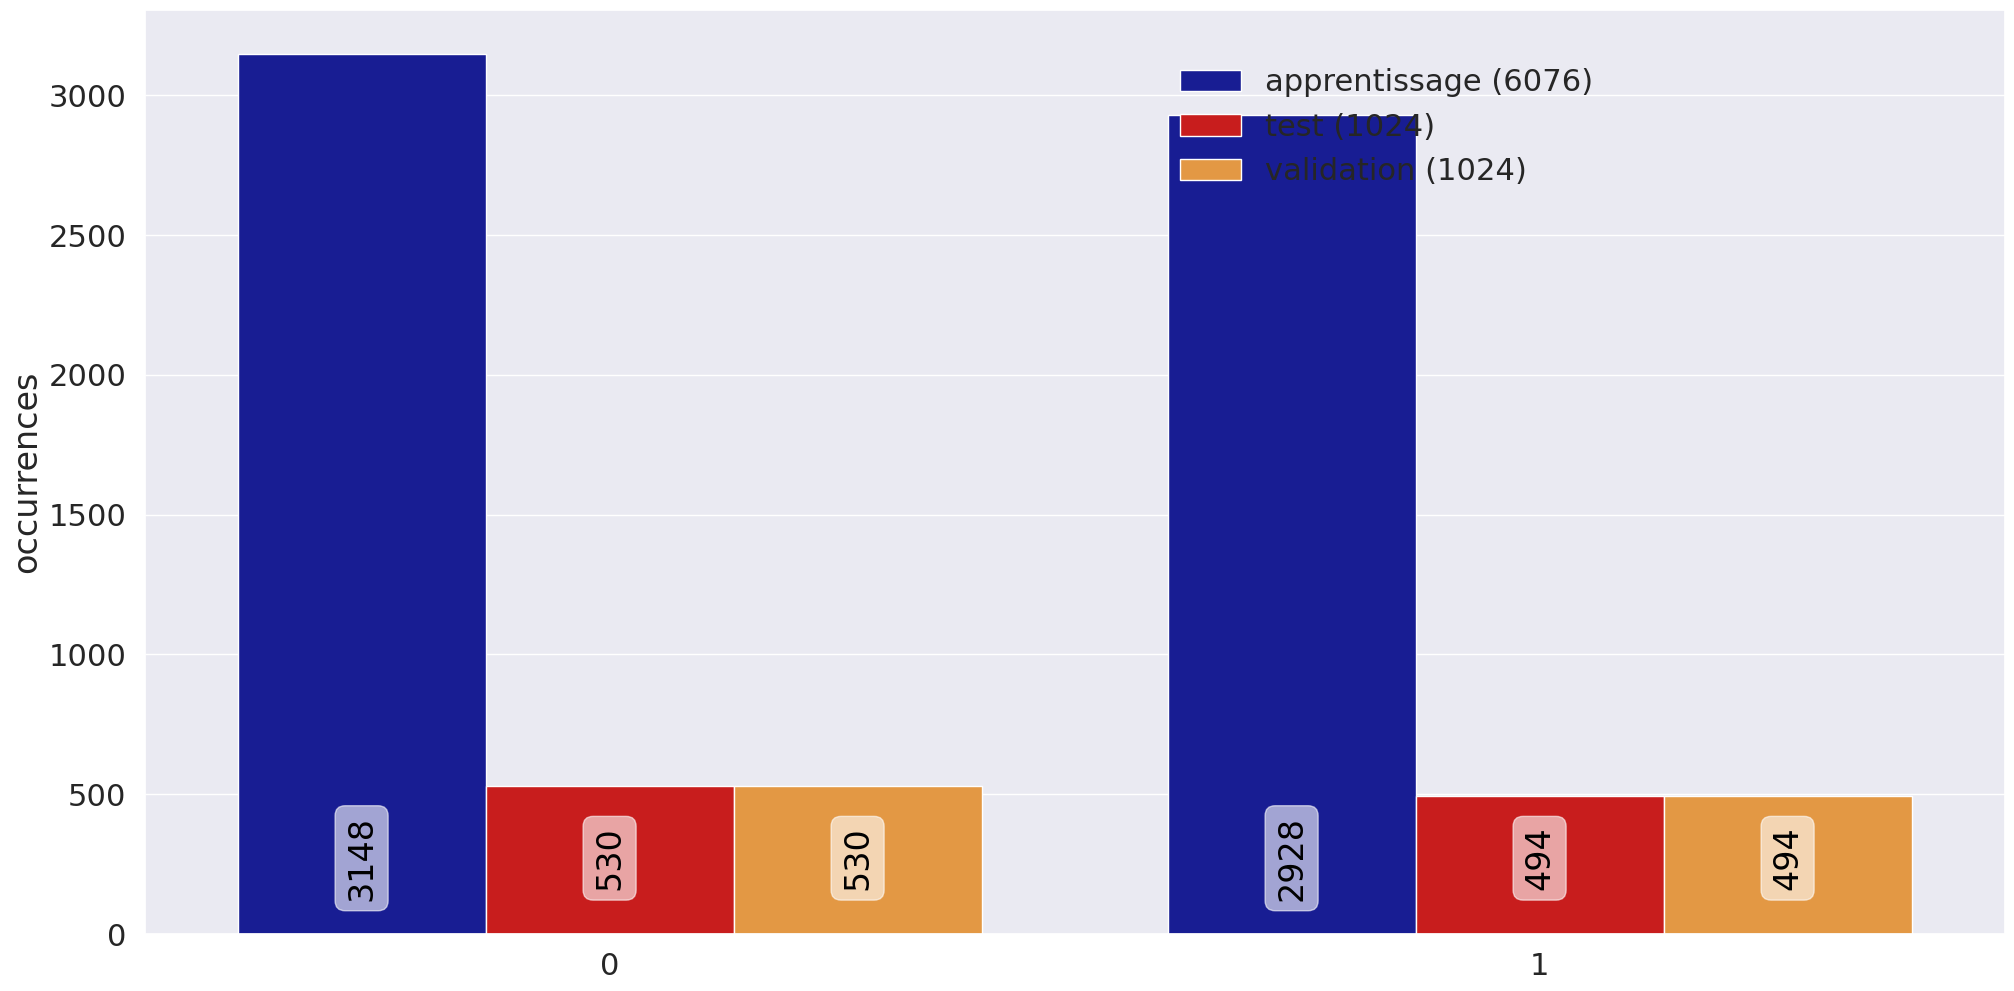

In [12]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(24,12))
afficheSeparationsBinaires(donnees, palette, ax, cible=cible)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Inversement des modalités de la cible</div></b>

In [13]:
y_trainI = y_train.apply(lambda x: 1 if x==0 else 0)
y_testI  = y_test.apply(lambda x: 1 if x==0 else 0)

In [14]:
y_trainI.sum(),y_train.sum(),y_testI.sum(),y_test.sum()

(3148, 2928, 530, 494)

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Déclaration du classificateur</div></b>

In [15]:
classificateur = LogisticRegression(
                C=0.81113,
                max_iter=800,
                penalty='l2',
                solver='lbfgs',
                n_jobs=-1
            )

classificateurI = LogisticRegression(
                C=0.81113,
                max_iter=800,
                penalty='l2',
                solver='lbfgs',
                n_jobs=-1
            )

classificateur.fit(X_train, y_train)
classificateurI.fit(X_train, y_trainI)

probabilites = classificateur.predict_proba(X_test)
predictions  = classificateur.predict(X_test) # 50%
observations = y_test.ravel()

probabilitesI = classificateurI.predict_proba(X_test)
predictionsI  = classificateurI.predict(X_test) # 50%
observationsI = y_testI.ravel()

accuracy     = accuracy_score (observations,predictions)
# precision    = precision_score(observations,predictions)
# sensibilite  = recall_score   (observations,predictions)
# logloss      = log_loss       (observations,predictions)
# hammingloss  = hamming_loss   (observations,predictions)
# jaccard      = jaccard_score  (observations,predictions)
# matthews     = matthews_corrcoef(observations,predictions)
# f1           = f1_score       (observations,predictions)
# fbeta05      = fbeta_score    (observations,predictions, beta=0.5)
# fbeta1       = fbeta_score    (observations,predictions, beta=1)
# fbeta2       = fbeta_score    (observations,predictions, beta=2)

# print(f""" 
# accuracy                   = {accuracy:0.4f} 
# precision                  = {precision:0.4f} 
# sensibilite                = {sensibilite :0.4f} 
# logloss                    = {logloss:0.4f} 
# hammingloss                = {hammingloss:0.4f} 
# jaccard                    = {jaccard:0.4f} 
# Matthews corr. coefficient = {matthews:0.4f} 
# f1                         = {f1:0.4f} 
# fbeta05                    = {fbeta05:0.4f} 
# fbeta1                     = {fbeta1:0.4f} 
# fbeta2                     = {fbeta2:0.4f} 
# """)

In [16]:
print(f"""
-------------------------------------------------------------------------------
         toxique = 1                    |           comestible = 1 
-------------------------------------------------------------------------------
accuracy                   = {accuracy_score   (observations,predictions)           :0.6f}   | accuracy                   = {accuracy_score   (observationsI,predictionsI)           :0.6f}
-------------------------------------------------------------------------------
precision                  = {precision_score  (observations,predictions)           :0.6f}   | precision                  = {precision_score  (observationsI,predictionsI)           :0.6f}
sensibilite                = {recall_score     (observations,predictions)           :0.6f}   | sensibilite                = {recall_score     (observationsI,predictionsI)           :0.6f}
logloss                    = {log_loss         (observations,predictions)           :0.6f}   | logloss                    = {log_loss         (observationsI,predictionsI)           :0.6f}
hammingloss                = {hamming_loss     (observations,predictions)           :0.6f}   | hammingloss                = {hamming_loss     (observationsI,predictionsI)           :0.6f}
jaccard                    = {jaccard_score    (observations,predictions)           :0.6f}   | jaccard                    = {jaccard_score    (observationsI,predictionsI)           :0.6f}
Matthews corr. coefficient = {matthews_corrcoef(observations,predictions)           :0.6f}   | Matthews corr. coefficient = {matthews_corrcoef(observationsI,predictionsI)           :0.6f}
f1                         = {f1_score         (observations,predictions)           :0.6f}   | f1                         = {f1_score         (observationsI,predictionsI)           :0.6f}
fbeta05                    = {fbeta_score      (observations,predictions, beta=0.5) :0.6f}   | fbeta05                    = {fbeta_score      (observationsI,predictionsI, beta=0.5) :0.6f}
fbeta1                     = {fbeta_score      (observations,predictions, beta=1)   :0.6f}   | fbeta1                     = {fbeta_score      (observationsI,predictionsI, beta=1)   :0.6f}
fbeta2                     = {fbeta_score      (observations,predictions, beta=2)   :0.6f}   | fbeta2                     = {fbeta_score      (observationsI,predictionsI, beta=2)   :0.6f}
""")


-------------------------------------------------------------------------------
         toxique = 1                    |           comestible = 1 
-------------------------------------------------------------------------------
accuracy                   = 0.957031   | accuracy                   = 0.957031
-------------------------------------------------------------------------------
precision                  = 0.946429   | precision                  = 0.967308
sensibilite                = 0.965587   | sensibilite                = 0.949057
logloss                    = 1.548751   | logloss                    = 1.548751
hammingloss                = 0.042969   | hammingloss                = 0.042969
jaccard                    = 0.915547   | jaccard                    = 0.919561
Matthews corr. coefficient = 0.914190   | Matthews corr. coefficient = 0.914190
f1                         = 0.955912   | f1                         = 0.958095
fbeta05                    = 0.950199   | fbeta05  

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Courbe ROC (Receiver Operating Caracteristic)</div></b>


toxique = 1 
Aire sous la courbe ROC(AUC) : 0.99008097 
comestible = 1
Aire sous la courbe ROC(AUC) : 0.99014590 
Score de prédiction à 50%    : 0.95703125


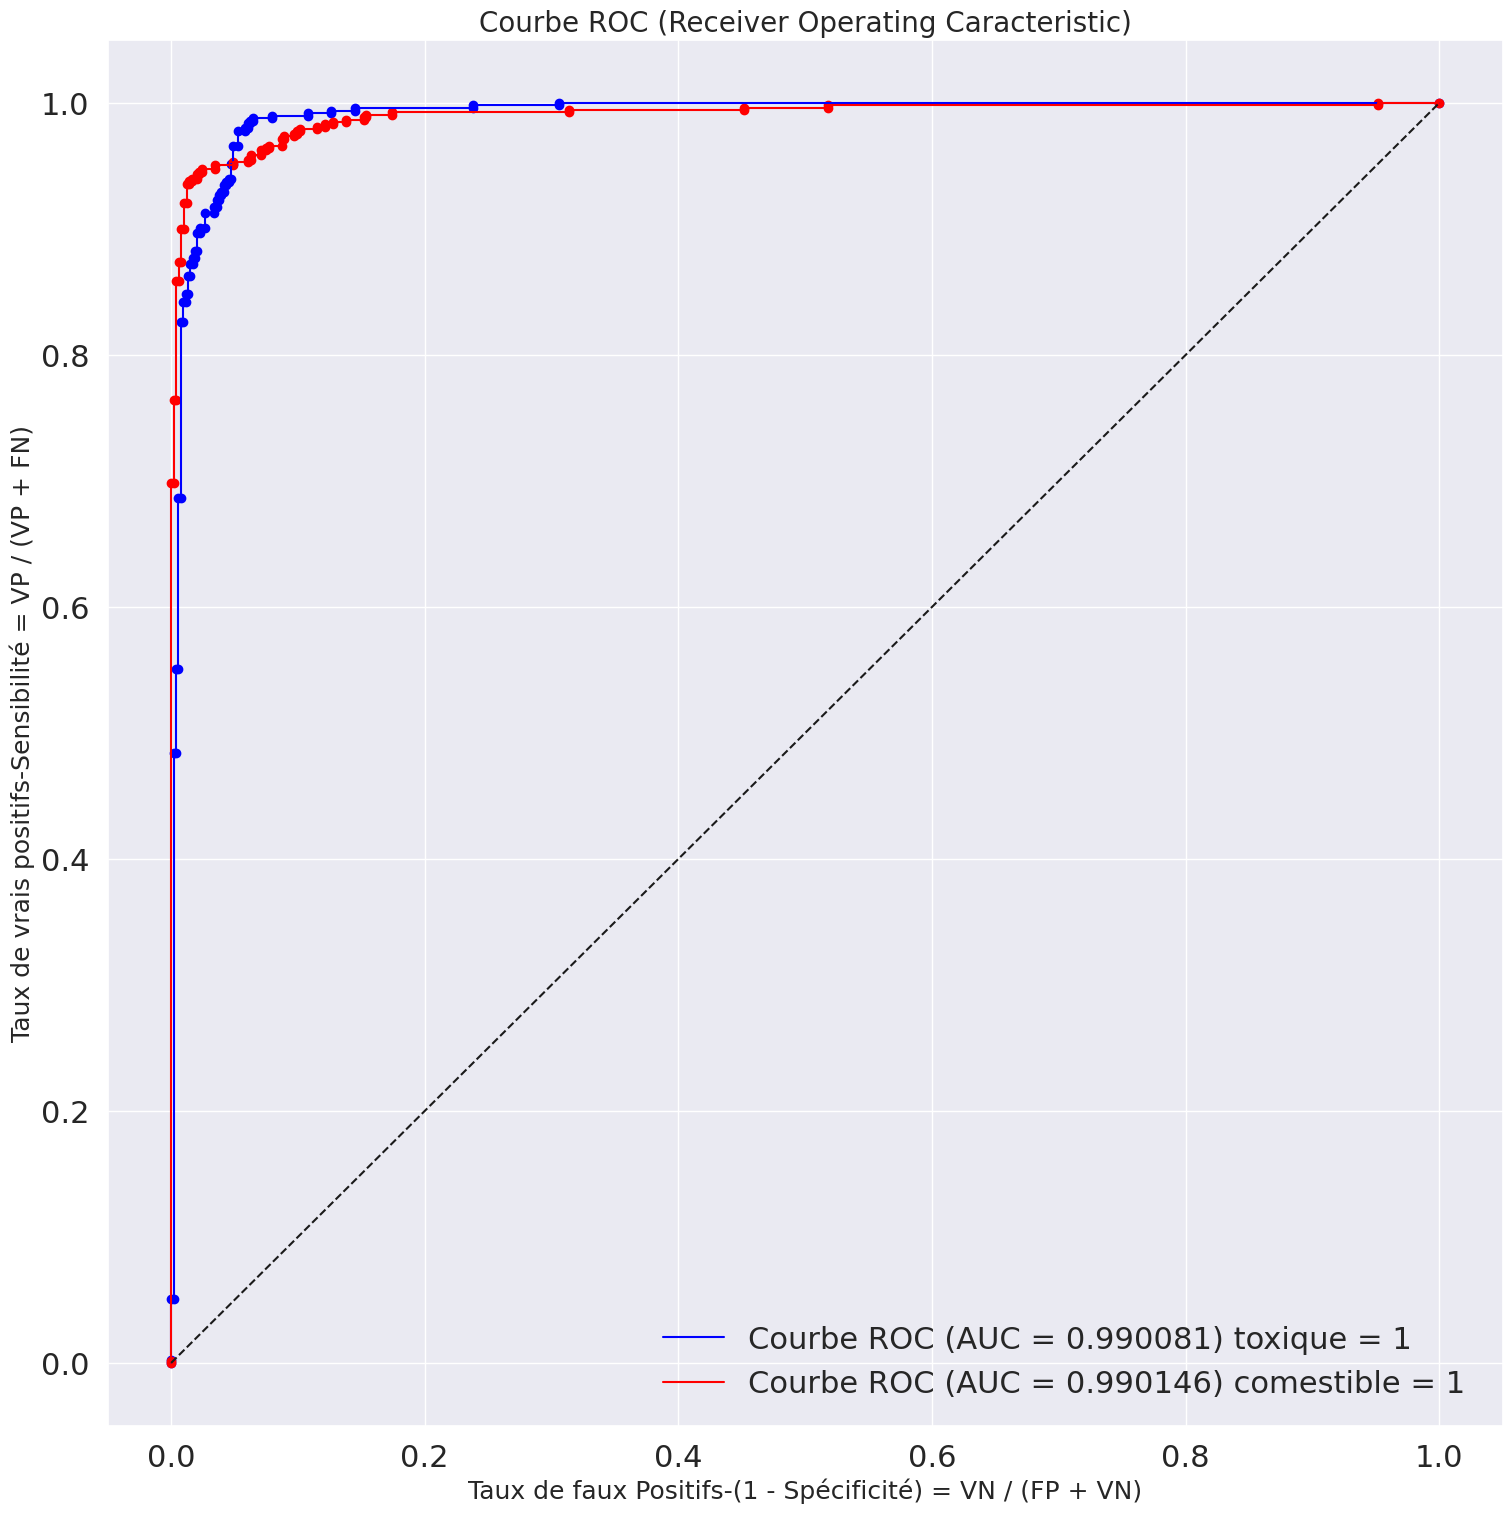

In [17]:
fauxPositifs, vraisPositifs, seuils = roc_curve(observations,probabilites[:, 1])
fauxPositifsI, vraisPositifsI, seuilsI = roc_curve(observationsI,probabilitesI[:, 1])

roc_auc = auc(fauxPositifs, vraisPositifs)
roc_aucI = auc(fauxPositifsI, vraisPositifsI)

print (f"""
toxique = 1 
Aire sous la courbe ROC(AUC) : {roc_auc:.8f} 
comestible = 1
Aire sous la courbe ROC(AUC) : {roc_aucI:.8f} 
Score de prédiction à 50%    : {accuracy:.8f}"""
)

plt.figure(figsize=(18, 18))
plt.scatter(fauxPositifs, vraisPositifs, color='blue')
plt.scatter(fauxPositifsI, vraisPositifsI, color='red')

plt.plot( fauxPositifs, vraisPositifs, label=f'Courbe ROC (AUC = {roc_auc:0.6f}) toxique = 1 ', color='blue')
plt.plot( fauxPositifsI, vraisPositifsI, label=f'Courbe ROC (AUC = {roc_aucI:0.6f}) comestible = 1 ', color='red')  

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('Taux de faux Positifs-(1 - Spécificité) = VN / (FP + VN)',size=18)
plt.ylabel('Taux de vrais positifs-Sensibilité = VP / (VP + FN)',size=18)
plt.title('Courbe ROC (Receiver Operating Caracteristic)',size=20)
plt.legend(loc="lower right");

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Probabilité de prédiction</div></b>

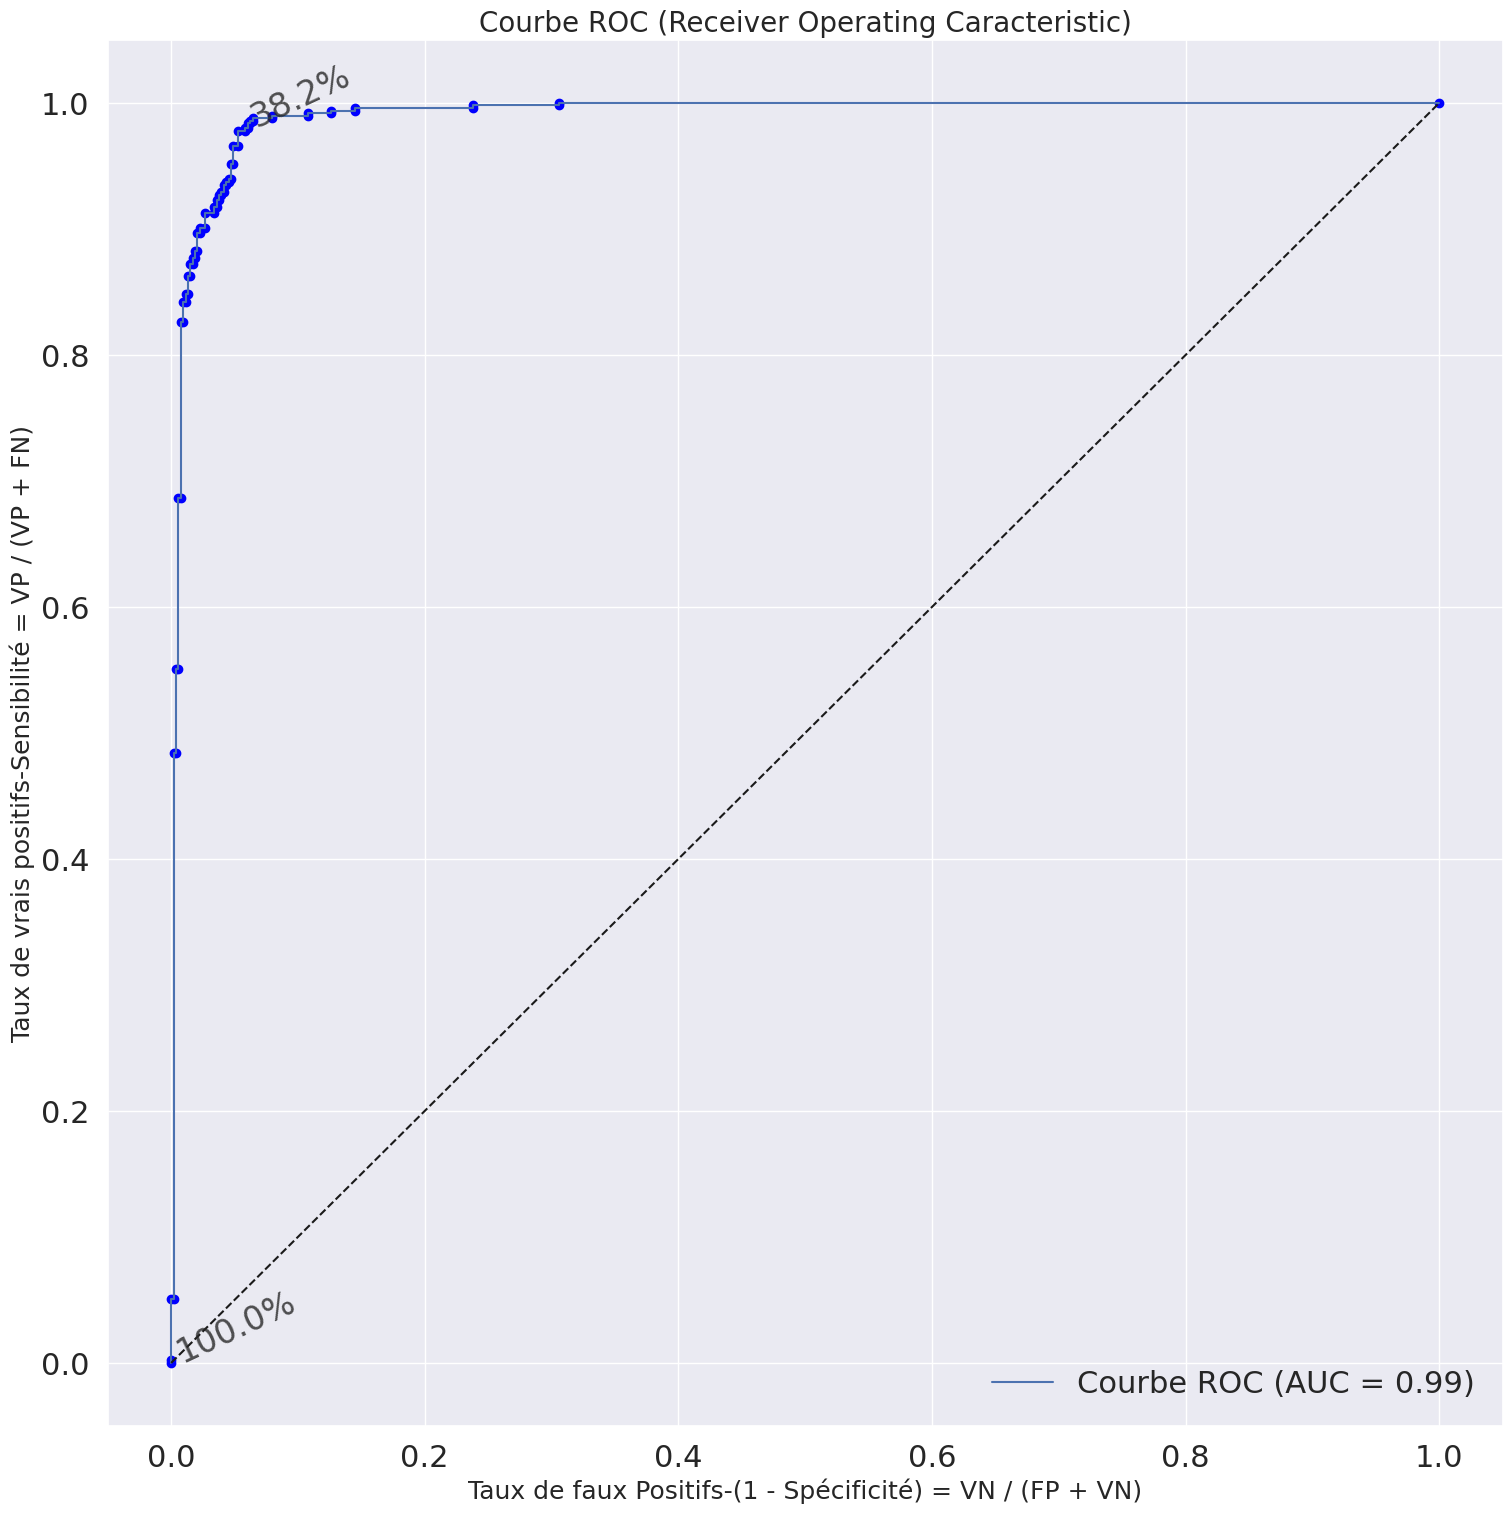

In [18]:
plt.figure(figsize=(18, 18))
plt.scatter(fauxPositifs, vraisPositifs, color='blue')
plt.plot( fauxPositifs, vraisPositifs, label='Courbe ROC (AUC = %0.2f)' % roc_auc)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

for i,t in enumerate(seuils[1:]*100):
    if i % 50 == 0 or int(t*10) == 500 :    
        plt.text(fauxPositifs[i], vraisPositifs[i]+0.001, f'{t:0.1f}%', rotation= 25, alpha=0.8) 
        
plt.xlabel('Taux de faux Positifs-(1 - Spécificité) = VN / (FP + VN)',size=18)
plt.ylabel('Taux de vrais positifs-Sensibilité = VP / (VP + FN)',size=18)
plt.title('Courbe ROC (Receiver Operating Caracteristic)',size=20)
plt.legend(loc="lower right");

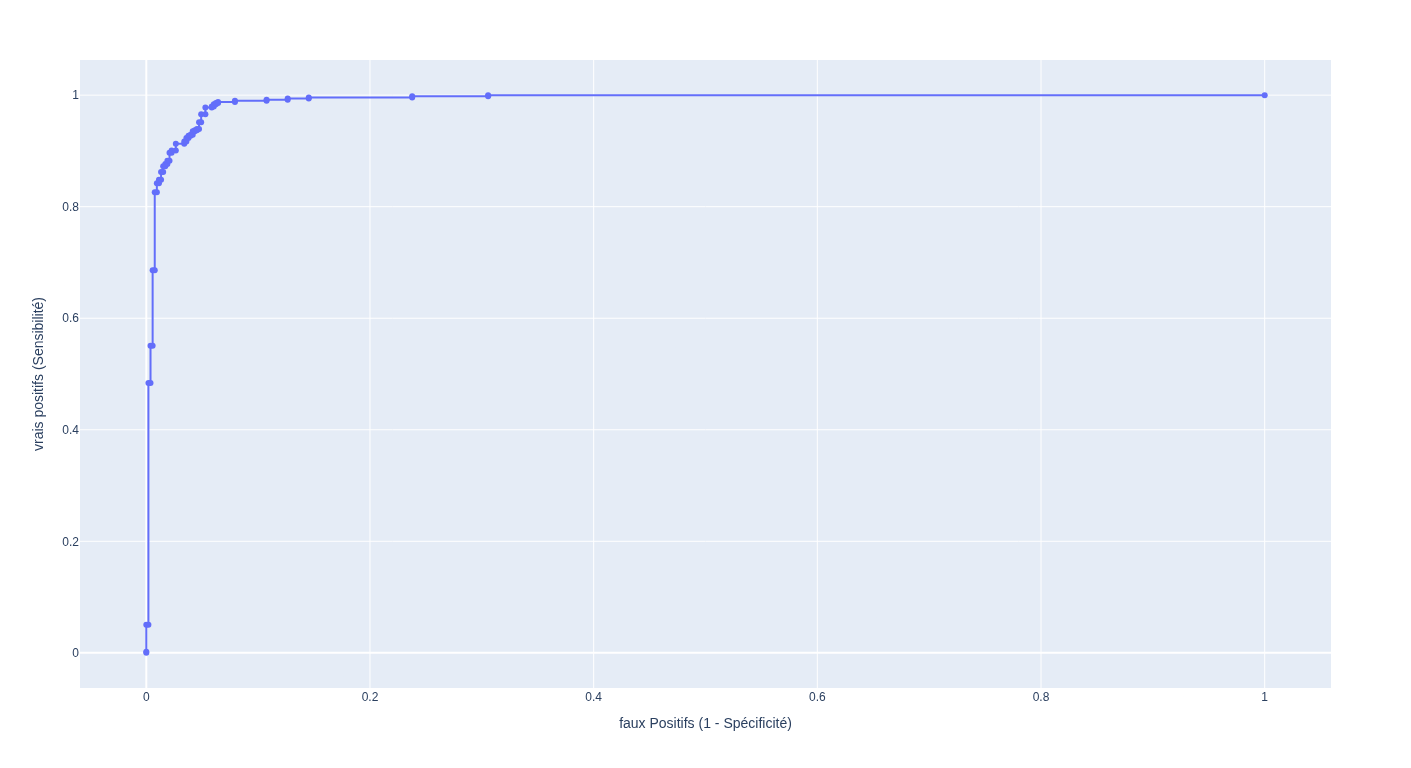

In [19]:
affichage = pd.DataFrame({'Probabilite':pd.Series(seuils).apply(lambda x : f'{x*100:0.2f}'),
                          'faux Positifs (1 - Spécificité)':fauxPositifs,
                          'vrais positifs (Sensibilité)':vraisPositifs
                         })
fig = px.line( affichage, 
                  x='faux Positifs (1 - Spécificité)', 
                  y='vrais positifs (Sensibilité)', 
                  hover_data=['Probabilite'],
                  
                  width=768,
                  height=768,
                  )
fig.update_traces(mode="markers+lines")#, hovertemplate=None)
# fig.update_layout(hovermode="y unified")

fig.show()

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Tableau des résultats</div></b>

In [20]:
pd.get_option('display.max_columns'),pd.get_option('display.max_rows')

(20, 60)

In [21]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
affichage = pd.DataFrame(probabilites*100,columns=['comestible','toxique']).sort_values(by ='toxique',ascending=False)

In [22]:
affichage['n'] = 1
affichage['nc'] = affichage['n'].transform('cumsum')
affichage['nc'] = affichage['nc'].astype('int32')
affichage.drop(columns='n',inplace=True)
affichage

,comestible,toxique,nc
505,0.003897,99.996103,1
473,0.008076,99.991924,2
399,0.009165,99.990835,3
514,0.010125,99.989875,4
438,0.012654,99.987346,5
504,0.013468,99.986532,6
920,0.014380,99.985620,7
377,0.015995,99.984005,8
485,0.017966,99.982034,9
593,0.065554,99.934446,10


In [23]:
affichage.columns

Index(['comestible', 'toxique', 'nc'], dtype='object')

In [24]:
affichage[(affichage.toxique < 54)&(affichage.toxique > 43)].style.format({"comestible":"{:0.2f}",
                                                                           "toxique":"{:0.2f}",}).background_gradient(cmap=plt.get_cmap('Blues'),axis=0)

,comestible,toxique,nc
550,46.18,53.82,500
729,47.50,52.50,501
274,47.67,52.33,502
646,48.67,51.33,503
745,49.48,50.52,504
39,50.61,49.39,505
717,51.46,48.54,506
669,52.23,47.77,507
722,53.94,46.06,508
663,55.99,44.01,509


In [25]:
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 60)

In [26]:
print(X_test.shape)
dfROC = pd.DataFrame({'Probabilite':probabilites[:,1],
                      'Observation':observations,
                      'Prediction':0
                    }).sort_values(by='Probabilite',ascending=False)
dfROC.head(5)

(1024, 21)


,Probabilite,Observation,Prediction
505,0.999961,1,0
473,0.999919,1,0
399,0.999908,1,0
514,0.999899,1,0
438,0.999873,1,0


In [27]:
def affichageMatrice(Predictions,Observations):
    matriceConfusion = pd.crosstab(Predictions,Observations)
    
    matriceConfusion["Total"] = matriceConfusion.sum(axis=1)
    matriceConfusion.loc["Total"] = matriceConfusion.iloc[:,:2].sum(axis=0)
    matriceConfusion.loc["Total","Total"] = 0
    matriceConfusion = matriceConfusion.astype('int32')
    
    return matriceConfusion.style.background_gradient( cmap=plt.get_cmap('Blues'))

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Prédiction à 50%</div></b>
<img src="https://raw.githubusercontent.com/rbizoi/IntelligenceEnDonneesDeSante/refs/heads/main/images/roc_list_proba.png" width="256">

In [28]:
df = dfROC
df.Prediction = df.Probabilite.apply(lambda x: 0 if x < .5 else 1)
affichageMatrice(df.Prediction,df.Observation)

Observation,0,1,Total
Prediction,,,
0,503,17,520
1,27,477,504
Total,530,494,0


In [29]:
df = dfROC
df.Prediction = df.Probabilite.round().astype('int8')
affichageMatrice(df.Prediction,df.Observation)

Observation,0,1,Total
Prediction,,,
0,503,17,520
1,27,477,504
Total,530,494,0


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Prédiction à 49,39 et 51,33%</div></b>
<img src="https://raw.githubusercontent.com/rbizoi/IntelligenceEnDonneesDeSante/refs/heads/main/images/roc_list_proba.png" width="256">

In [30]:
df = dfROC
df.Prediction = df.Probabilite.apply(lambda x: 0 if x < .5132 else 1)
affichageMatrice(df.Prediction,df.Observation)

Observation,0,1,Total
Prediction,,,
0,504,17,521
1,26,477,503
Total,530,494,0


In [31]:
df = dfROC
df.Prediction = df.Probabilite.apply(lambda x: 0 if x < .4938 else 1)
affichageMatrice(df.Prediction,df.Observation)

Observation,0,1,Total
Prediction,,,
0,502,17,519
1,28,477,505
Total,530,494,0


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Prédiction à 43,44%</div></b>
<img src="https://raw.githubusercontent.com/rbizoi/IntelligenceEnDonneesDeSante/refs/heads/main/images/roc_list_proba.png" width="256">

In [32]:
df = dfROC
df.Prediction = df.Probabilite.apply(lambda x: 0 if x < .4343 else 1)
affichageMatrice(df.Prediction,df.Observation)

Observation,0,1,Total
Prediction,,,
0,502,12,514
1,28,482,510
Total,530,494,0


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Calculs des métriques</div></b>
<table>
    <tr>                                                                                   
         <th><b><div style='padding:15px;color:#030aa7;font-size:200%;text-align: center'></div></b></th>
         <th><b><div style='padding:15px;color:#030aa7;font-size:200%;text-align: center'>Matrice de confusion</div></b></th>
    </tr>
    <tr>                                                                                   
         <th>
                 <img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/metriques/donnees_classif.png" width="512">
             </th>
             <th>
                 <img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/metriques/matrice_confusion.png">
         </th>
    </tr>
</table>    



In [33]:
def calculMatriceConfusionMetriques(donnees, seuil, Prevalence):
    donnees.Prediction = donnees.Probabilite.apply(lambda x: 0 
                                         if x < seuil else 1)
    vraisNegatifs     = confusion_matrix(donnees.Observation, donnees.Prediction)[0, 0]
    fauxPositifs      = confusion_matrix(donnees.Observation, donnees.Prediction)[0, 1]
    fauxNegatifs      = confusion_matrix(donnees.Observation, donnees.Prediction)[1, 0]
    vraisPositifs     = confusion_matrix(donnees.Observation, donnees.Prediction)[1, 1]

    Sensibilite       = vraisPositifs / (vraisPositifs + fauxNegatifs)
    Specificite       = vraisNegatifs / (fauxPositifs  + vraisNegatifs)

    Precision         = vraisPositifs / (vraisPositifs + fauxPositifs) # 
    # Precision         = 0 if pd.isna(Precision) else Precision
    
    F1Score           = 2 * Precision * Sensibilite / (Precision + Sensibilite) # 
    # F1Score           = 0 if pd.isna(F1Score) else F1Score
    
    valeurPreditePositive = Sensibilite*Prevalence / (Sensibilite*Prevalence + ((1 - Specificite)*(1-Prevalence)))
    valeurPrediteNegative = Specificite*(1-Prevalence)/(Prevalence*(1-Sensibilite) + (Specificite*(1-Prevalence)))
    
    return [Sensibilite,Specificite,Precision,F1Score,
            valeurPreditePositive,valeurPrediteNegative,
            vraisPositifs,vraisNegatifs,fauxNegatifs,fauxPositifs]

In [34]:
def calculMetriquesCourbes(donnees, nombreIterations = 10000):
    Sensibilite,Specificite,Precision,F1Score,valeurPreditePositive,valeurPrediteNegative,vraisPositifs,vraisNegatifs,fauxNegatifs,fauxPositifs = \
                            dict(),dict(),dict(),dict(),dict(),dict(),dict(),dict(),dict(),dict()
    
    Prevalence = donnees.Observation.sum()/donnees.Observation.count()
    
    # nb = 10000
    for i in range(1,nombreIterations+1):
        t = (nombreIterations - i) / nombreIterations
        Sensibilite[t],Specificite[t],Precision[t],F1Score[t],\
        valeurPreditePositive[t],valeurPrediteNegative[t],\
        vraisPositifs[t],vraisNegatifs[t],fauxNegatifs[t],fauxPositifs[t] = calculMatriceConfusionMetriques(donnees, t, Prevalence)   
    
    metriques = pd.concat([pd.Series(Sensibilite,name='Sensibilite'),
                            pd.Series(Specificite,name='Specificite'),
                            pd.Series(Precision,name='Precision'),
                            pd.Series(F1Score,name='F1Score'),
                            pd.Series(valeurPreditePositive,name='valeurPreditePositive'),
                            pd.Series(valeurPrediteNegative,name='valeurPrediteNegative'),
                            pd.Series(vraisPositifs,name='vraisPositifs'),
                            pd.Series(vraisNegatifs,name='vraisNegatifs'),
                            pd.Series(fauxNegatifs,name='fauxNegatifs'),
                            pd.Series(fauxPositifs,name='fauxPositifs')],axis=1)
    metriques.reset_index(inplace=True)
    metriques.columns = ['Probabilite'] + list(metriques.columns[1:])
    metriques.loc[0,['Precision','F1Score','valeurPreditePositive']] = 0
    return metriques
    

In [35]:
metriques = calculMetriquesCourbes(dfROC, nombreIterations = 10000)

In [36]:
metriques.head()

,Probabilite,Sensibilite,Specificite,Precision,F1Score,valeurPreditePositive,valeurPrediteNegative,vraisPositifs,vraisNegatifs,fauxNegatifs,fauxPositifs
0,0.9999,0.006073,1.0,0.0,0.000000,0.0,0.519099,3,530,491,0
1,0.9998,0.018219,1.0,1.0,0.035785,1.0,0.522167,9,530,485,0
2,0.9997,0.018219,1.0,1.0,0.035785,1.0,0.522167,9,530,485,0
3,0.9996,0.018219,1.0,1.0,0.035785,1.0,0.522167,9,530,485,0
4,0.9995,0.018219,1.0,1.0,0.035785,1.0,0.522167,9,530,485,0


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Courbe ROC (Receiver Operating Caracteristic)</div></b>

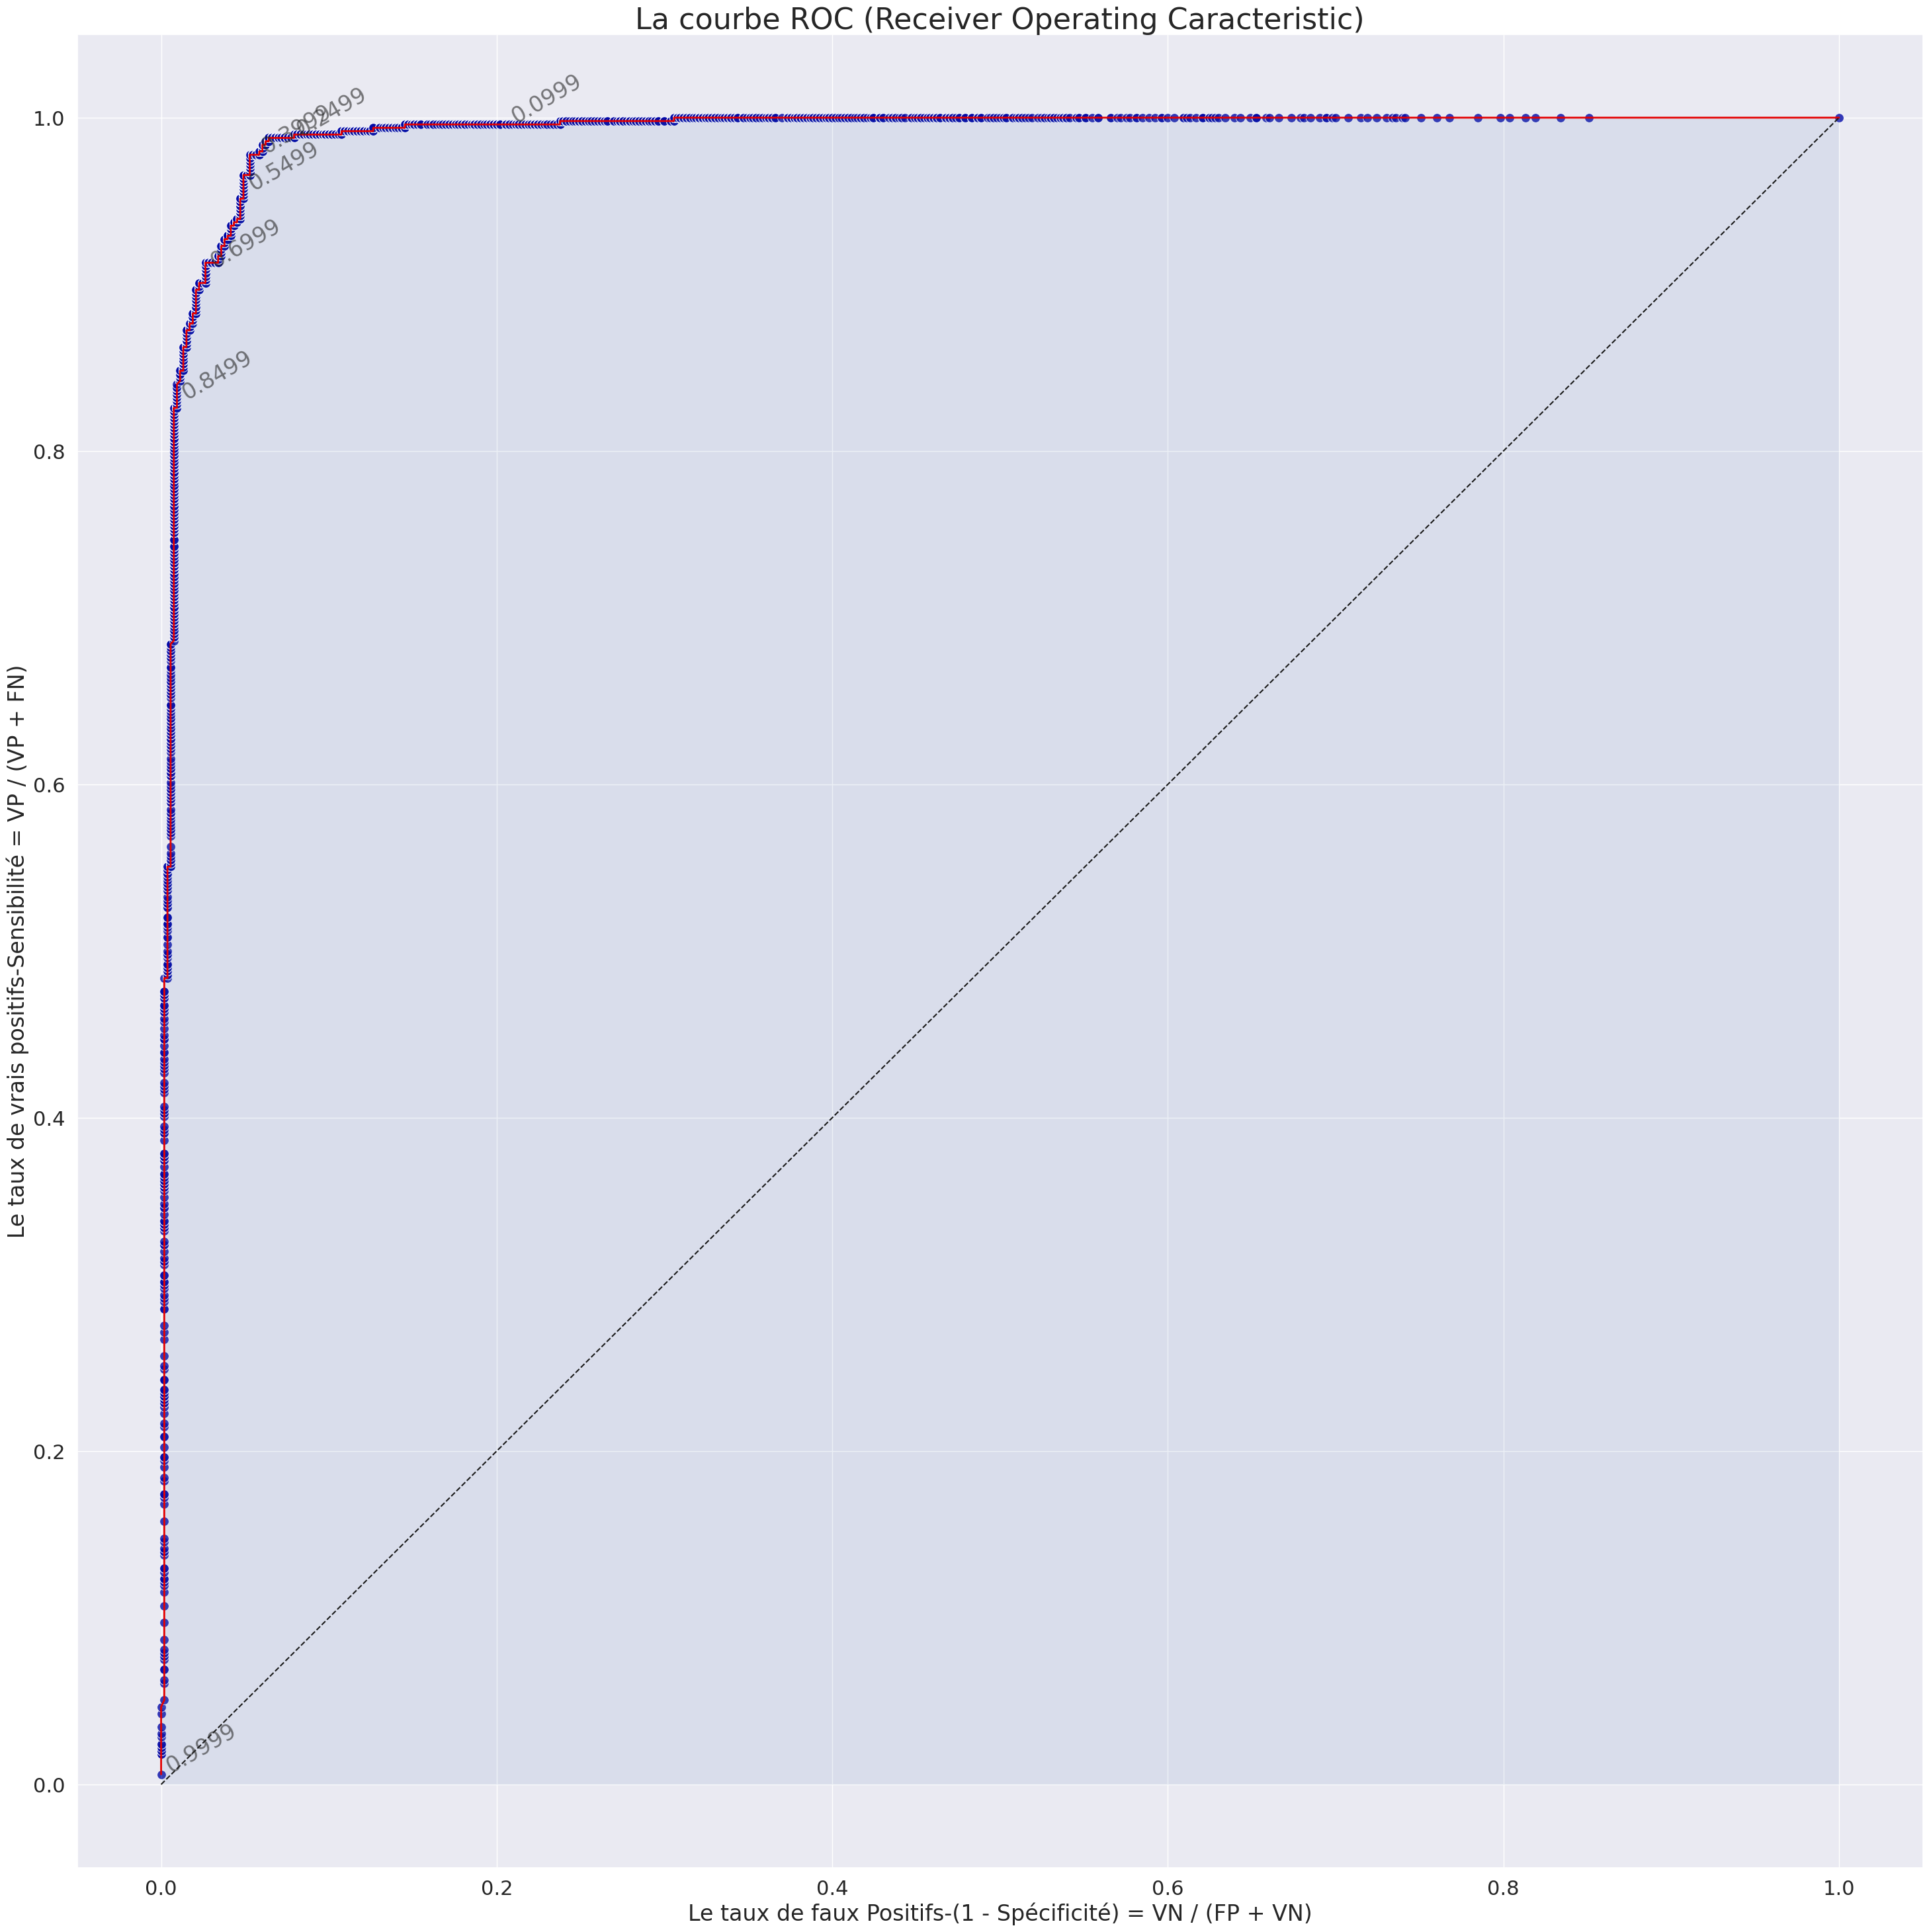

In [37]:
plt.figure(figsize=(36,36))

graph = sns.lineplot(x         = 1 - metriques.Specificite, 
                     y         = metriques.Sensibilite, 
                     estimator = None, 
                     lw        = 2, 
                     color     = palette[1])

sns.scatterplot     (x         = 1 - metriques.Specificite, 
                     y         = metriques.Sensibilite, 
                     alpha     = 0.8,   
                     s         = 100,
                     color     = palette[0],
                     ax        = graph,);

graph.fill_between(1 - metriques.Specificite, metriques.Sensibilite, step='post', alpha=0.1)
graph.plot([0, 1], [0, 1], 'k--')

for i, metrique in metriques.iterrows():
    if i % 1500 == 0 :
        graph.text(1 - metrique['Specificite']+0.001,metrique['Sensibilite']+0.001, metrique['Probabilite'], rotation= 30, alpha=0.6,size=24) 

graph.set_xlabel('Le taux de faux Positifs-(1 - Spécificité) = VN / (FP + VN)')
graph.set_ylabel('Le taux de vrais positifs-Sensibilité = VP / (VP + FN)')  
graph.set_title('La courbe ROC (Receiver Operating Caracteristic)',size=32);

In [38]:
metriques.head()

,Probabilite,Sensibilite,Specificite,Precision,F1Score,valeurPreditePositive,valeurPrediteNegative,vraisPositifs,vraisNegatifs,fauxNegatifs,fauxPositifs
0,0.9999,0.006073,1.0,0.0,0.000000,0.0,0.519099,3,530,491,0
1,0.9998,0.018219,1.0,1.0,0.035785,1.0,0.522167,9,530,485,0
2,0.9997,0.018219,1.0,1.0,0.035785,1.0,0.522167,9,530,485,0
3,0.9996,0.018219,1.0,1.0,0.035785,1.0,0.522167,9,530,485,0
4,0.9995,0.018219,1.0,1.0,0.035785,1.0,0.522167,9,530,485,0


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Courbe ROC (Receiver Operating Caracteristic) avec plotly</div></b>

In [39]:
affichage = metriques[::1].copy()
affichage['(1 - Spécificité)'] = 1 - affichage.Specificite
affichage.Probabilite = (affichage.Probabilite*100).round(2)

fig = px.line( affichage, 
                  x='(1 - Spécificité)', 
                  y='Sensibilite', 
                  hover_data=['Probabilite','F1Score','Precision','vraisPositifs','fauxPositifs','vraisNegatifs','fauxNegatifs'],
                  width=1024,
                  height=1024,
                  )

fig.update_layout(
    hovermode="y unified",
    hoverlabel=dict(
        bgcolor="white",
        font_size=16,
        font_family="Courier New, monospace",
    )
)

fig.update_traces(
    mode="lines+markers",
    hovertemplate =
                "<b>Probabilité       : %{customdata[0]:.2f}%</b><br>"+
                "Sensibilité       : %{y:.4f}<br>"+
                "(1 - Spécificité) : %{x:.4f}<br>"+
                "Précision         : %{customdata[2]:.4f}<br>" +
                "<b>F1                : %{customdata[1]:.4f}</b><br>" +
                "vrais Positifs    : %{customdata[3]:d}<br>" +
                "faux Positifs     : %{customdata[4]:d}<br>" +
                "vrais Négatifs    : %{customdata[5]:d}<br>" +
                "faux Négatifs     : %{customdata[6]:d}" ,
                # "<extra></extra>",
)


fig.show()

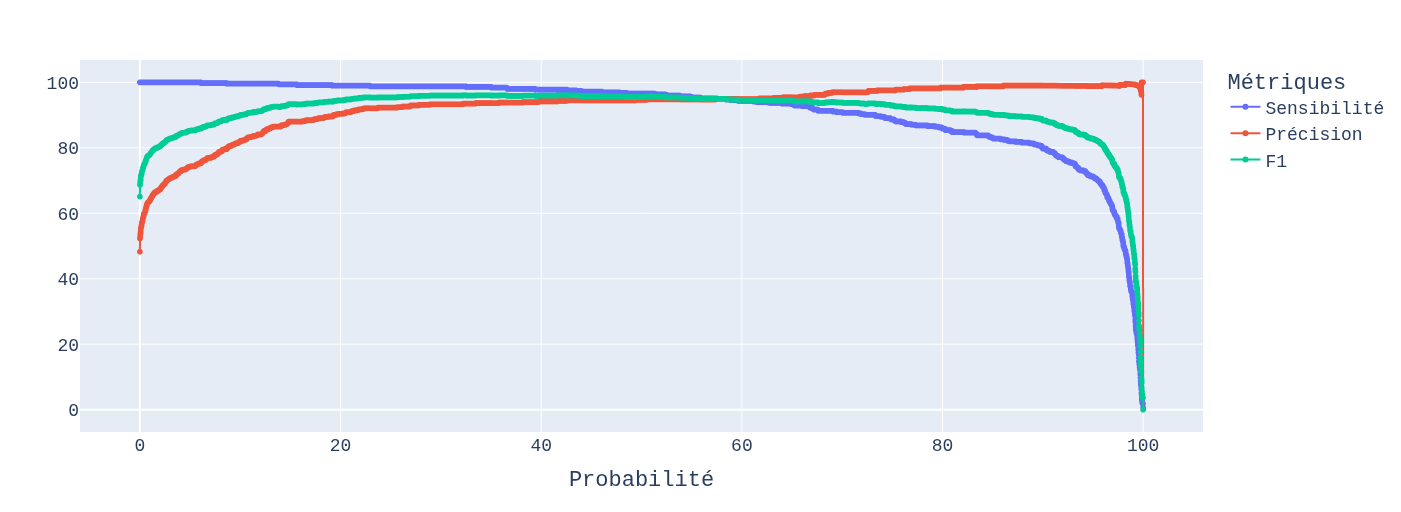

In [40]:
affichage = metriques.assign(Probabilité = metriques.Probabilite*100,
                             Sensibilité = metriques.Sensibilite*100,
                             Précision   = metriques.Precision*100,
                             F1          = metriques.F1Score*100
                             ).melt(id_vars=['Probabilité'],value_vars=['Sensibilité', 'Précision', 'F1'])
fig = px.line( affichage[::1], 
                  x='Probabilité', 
                  y='value', 
                  color='variable',
                  width=1024,
                  height=512,
                  )

fig.update_traces(mode="markers+lines")#, hovertemplate=None)

fig.update_layout(
    hovermode="x unified",
    hoverlabel=dict(
        bgcolor="white",
        font_size=16,
        font_family="Courier New, monospace"
    ),    
    # title="Plot Title",
    xaxis_title="Probabilité",
    yaxis_title="",
    legend_title="Métriques",
    font=dict(
        family="Courier New, monospace",
        size=18,
    )    
)

fig.show()

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Prédiction à 57,65%</div></b>
<table>
    <tr>                                                                                   
         <th> <img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/metriques/choix_se=pr.png" width="512"></th>
         </th>
    </tr>
</table>

In [45]:
df = dfROC
df.Prediction = df.Probabilite.apply(lambda x: 0 if x < .5765 else 1)
affichageMatrice(df.Prediction,df.Observation)

Observation,0,1,Total
Prediction,,,
0,505,25,530
1,25,469,494
Total,530,494,0


In [42]:
metriques.loc[(metriques.Probabilite < .5768)&(metriques.Probabilite > .5764),['Probabilite', 'F1Score','vraisPositifs','vraisNegatifs', 'fauxNegatifs', 'fauxPositifs' ]].style.background_gradient(cmap=plt.get_cmap('Blues'),axis=0)

,Probabilite,F1Score,vraisPositifs,vraisNegatifs,fauxNegatifs,fauxPositifs
4232,0.576700,0.949393,469,505,25,25
4233,0.576600,0.949393,469,505,25,25
4234,0.576500,0.949393,469,505,25,25


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Changement du pas de calcul</div></b>

In [43]:
metriques = calculMetriquesCourbes(dfROC, nombreIterations = 5)

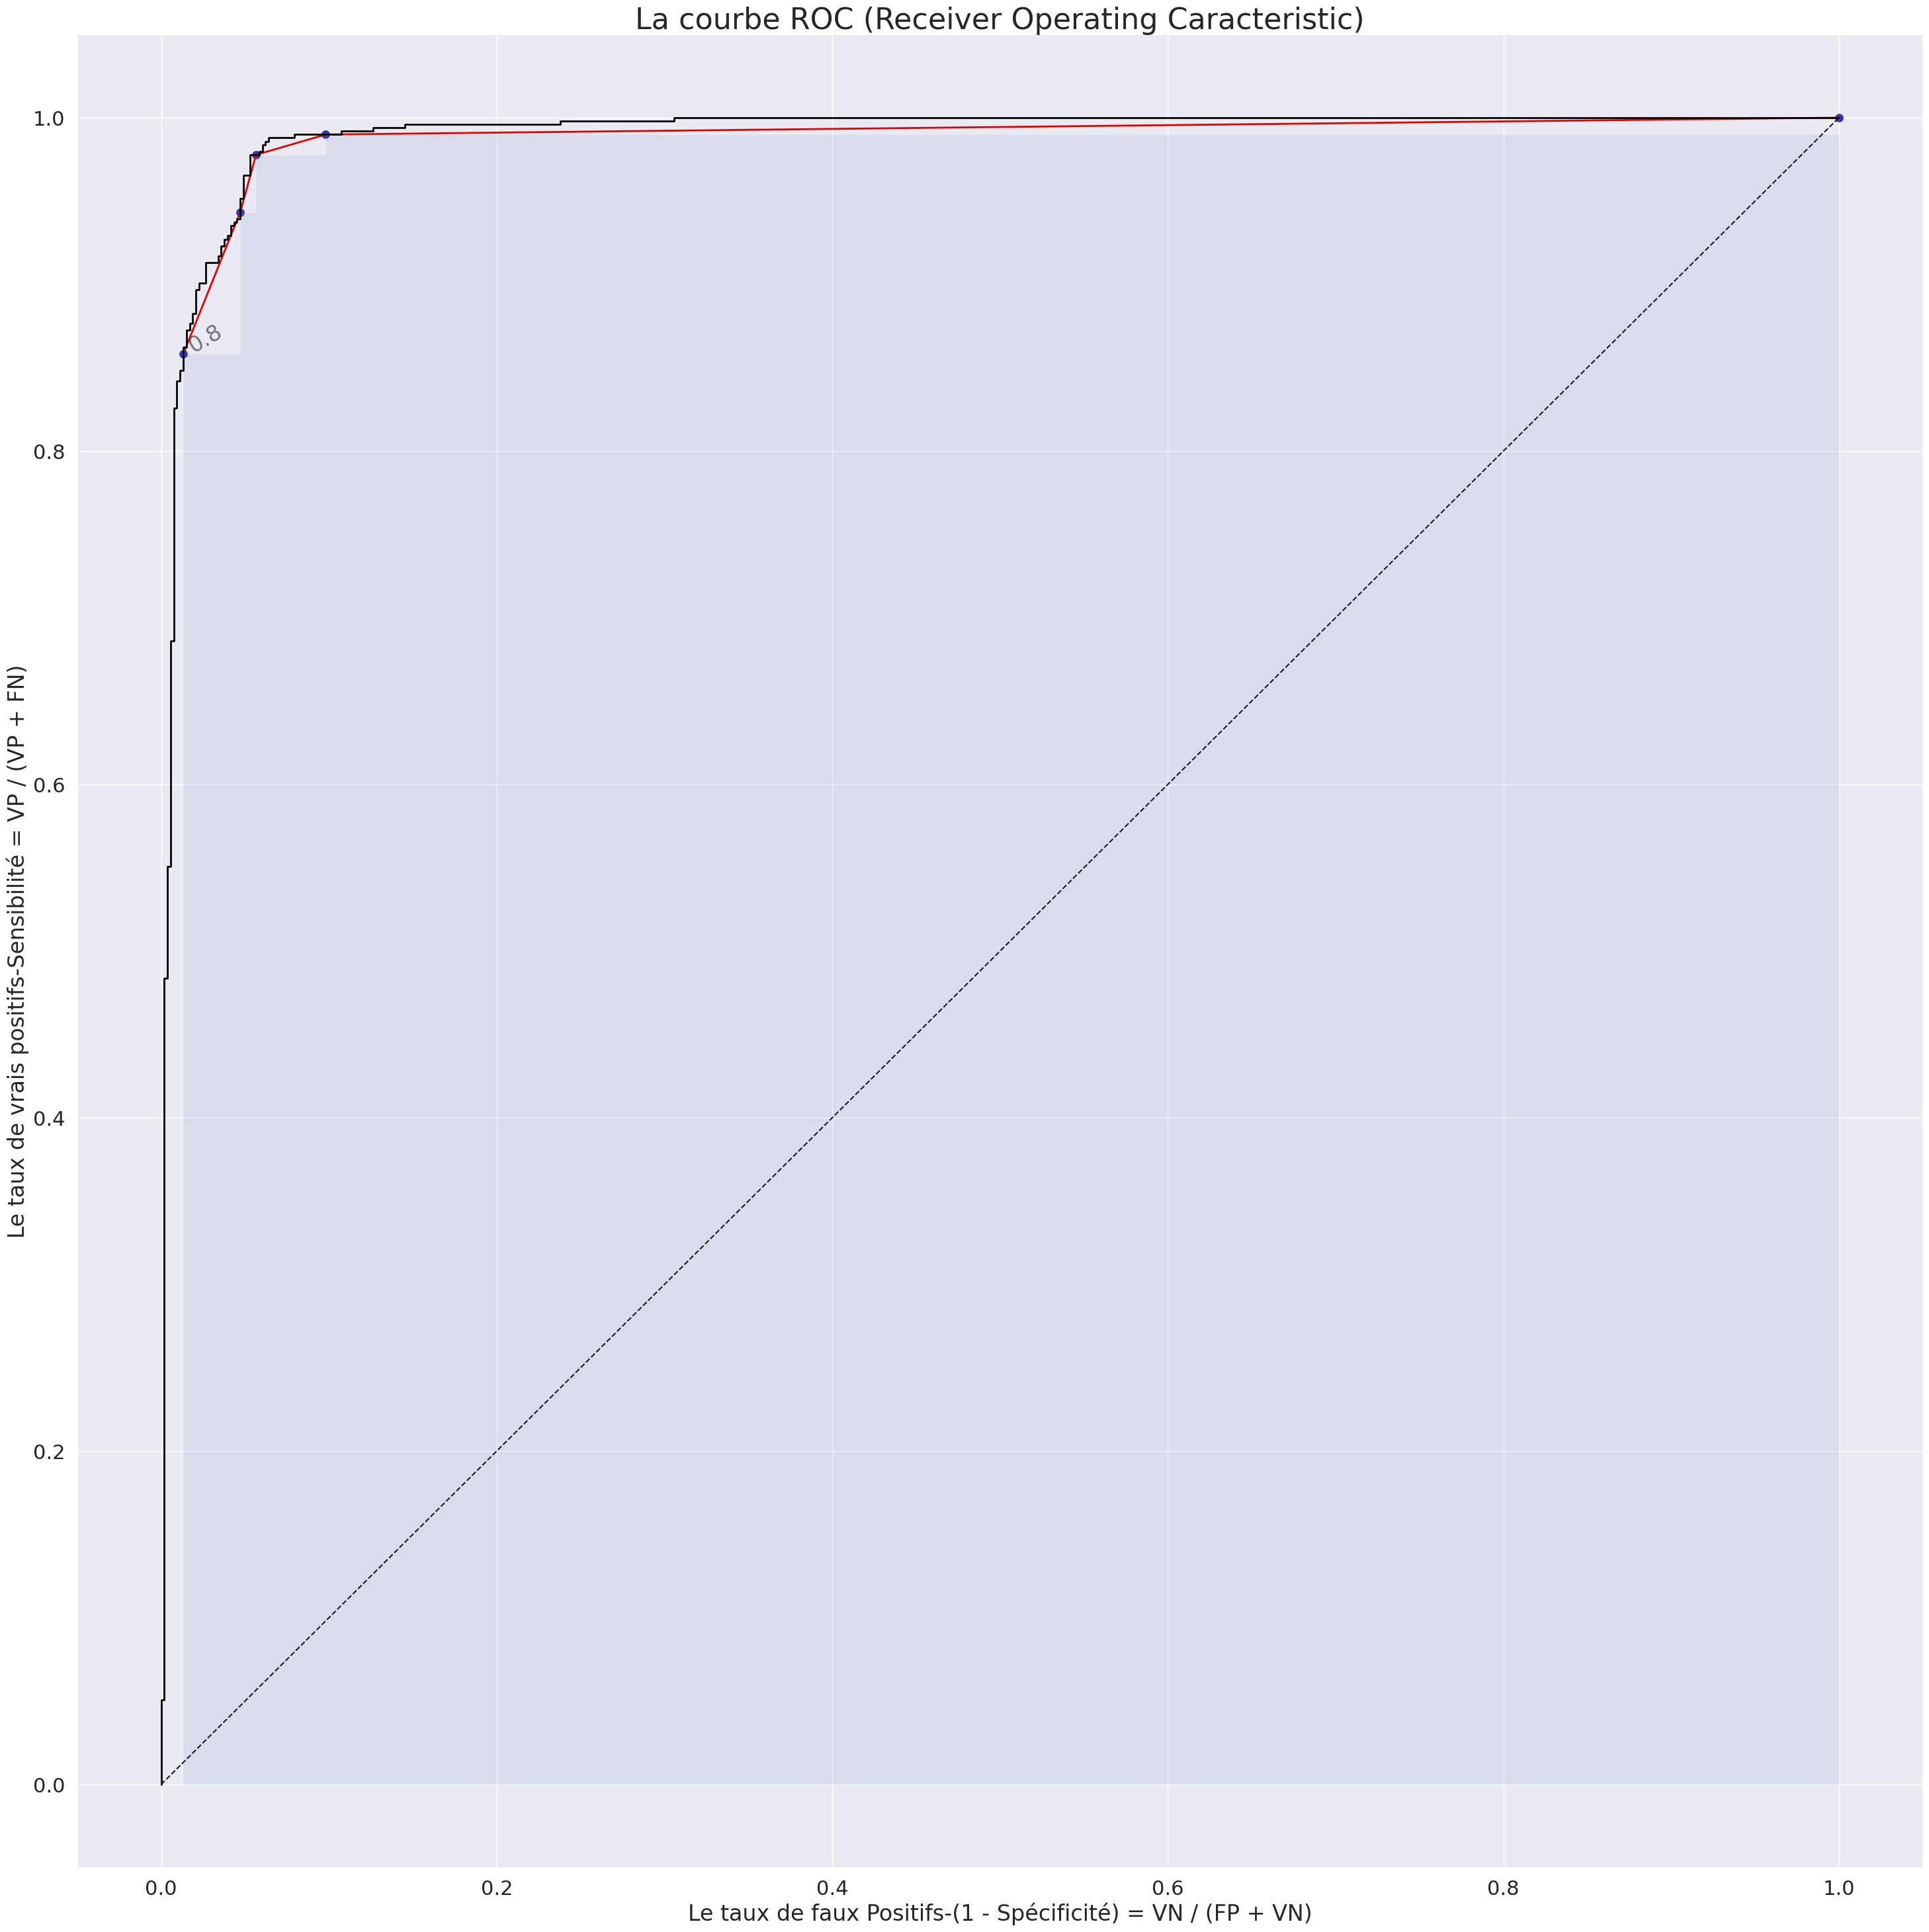

In [44]:
plt.figure(figsize=(36,36))

graph = sns.lineplot(x         = 1 - metriques.Specificite, 
                     y         = metriques.Sensibilite, 
                     estimator = None, 
                     lw        = 2, 
                     color     = palette[1])

sns.scatterplot     (x         = 1 - metriques.Specificite, 
                     y         = metriques.Sensibilite, 
                     alpha     = 0.8,   
                     s         = 100,
                     color     = palette[0],
                     ax        = graph,);

graph = sns.lineplot(x         = fauxPositifs,
                     y         = vraisPositifs,
                     estimator = None, 
                     lw        = 2, 
                     color     = 'black',
                    )

graph.fill_between(1 - metriques.Specificite, metriques.Sensibilite, step='post', alpha=0.1)
graph.plot([0, 1], [0, 1], 'k--')

for i, metrique in metriques.iterrows():
    if i % 1500 == 0 :
        graph.text(1 - metrique['Specificite']+0.001,metrique['Sensibilite']+0.001, metrique['Probabilite'], rotation= 30, alpha=0.6,size=24) 

graph.set_xlabel('Le taux de faux Positifs-(1 - Spécificité) = VN / (FP + VN)')
graph.set_ylabel('Le taux de vrais positifs-Sensibilité = VP / (VP + FN)')  
graph.set_title('La courbe ROC (Receiver Operating Caracteristic)',size=32);